In [1]:
!pip install networkx

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

In [3]:
from google.colab import files
files.upload()

mean_b0 = np.load("mean_b0.npy")
mean_d2 = np.load("mean_d2.npy")
mean_diff = np.load("mean_diff.npy")

region_labels = np.load("region_labels.npy", allow_pickle=True)
region_labels = list(region_labels)

Saving mean_b0.npy to mean_b0.npy
Saving mean_d2.npy to mean_d2.npy
Saving mean_diff.npy to mean_diff.npy
Saving region_labels.npy to region_labels.npy


In [4]:
print(mean_b0.shape)
print(mean_d2.shape)
print(mean_diff.shape)
print(len(region_labels))

(48, 48)
(48, 48)
(48, 48)
48


## Goal

Convert the average functional connectivity matrices into brain graphs
and identify regions whose network importance changes after ketamine.

In [5]:
G_b0 = nx.from_numpy_array(mean_b0)
G_d2 = nx.from_numpy_array(mean_d2)

In [6]:
mapping = {i: region_labels[i] for i in range(len(region_labels))}

G_b0 = nx.relabel_nodes(G_b0, mapping)
G_d2 = nx.relabel_nodes(G_d2, mapping)

In [11]:
mean_b0_no_diag = mean_b0.copy()
mean_d2_no_diag = mean_d2.copy()

np.fill_diagonal(mean_b0_no_diag, 0)
np.fill_diagonal(mean_d2_no_diag, 0)

In [12]:
baseline_strength = mean_b0_no_diag.sum(axis=1)
ketamine_strength = mean_d2_no_diag.sum(axis=1)

In [13]:
strength_df = pd.DataFrame({
    "region": region_labels,
    "baseline_strength": baseline_strength,
    "ketamine_strength": ketamine_strength
})

strength_df["delta_strength"] = (
    strength_df["ketamine_strength"] - strength_df["baseline_strength"]
)

strength_df.head()

,region,baseline_strength,ketamine_strength,delta_strength
0,Frontal Pole,14.866869,14.582963,-0.283906
1,Insular Cortex,7.394564,7.662189,0.267626
2,Superior Frontal Gyrus,-0.498127,1.292995,1.791122
3,Middle Frontal Gyrus,-6.300618,-4.224411,2.076208
4,"Inferior Frontal Gyrus, pars triangularis",9.303741,7.977839,-1.325902


In [14]:
top_strength_regions = strength_df.sort_values(
    "delta_strength",
    ascending=False
).head(10)

top_strength_regions

,region,baseline_strength,ketamine_strength,delta_strength
29,"Cingulate Gyrus, posterior division",6.470891,14.594311,8.123420
13,"Inferior Temporal Gyrus, anterior division",3.054308,11.172624,8.118316
20,Angular Gyrus,5.894927,13.641253,7.746326
25,Juxtapositional Lobule Cortex (formerly Supple...,1.270566,7.401891,6.131326
10,"Middle Temporal Gyrus, anterior division",2.677691,8.374462,5.696771
46,Supracalcarine Cortex,-0.624912,4.038893,4.663805
39,Occipital Fusiform Gyrus,0.775443,4.333279,3.557836
6,Precentral Gyrus,-1.281536,2.025641,3.307178
42,Parietal Opercular Cortex,9.988762,13.183900,3.195138
28,"Cingulate Gyrus, anterior division",9.369681,12.519693,3.150012


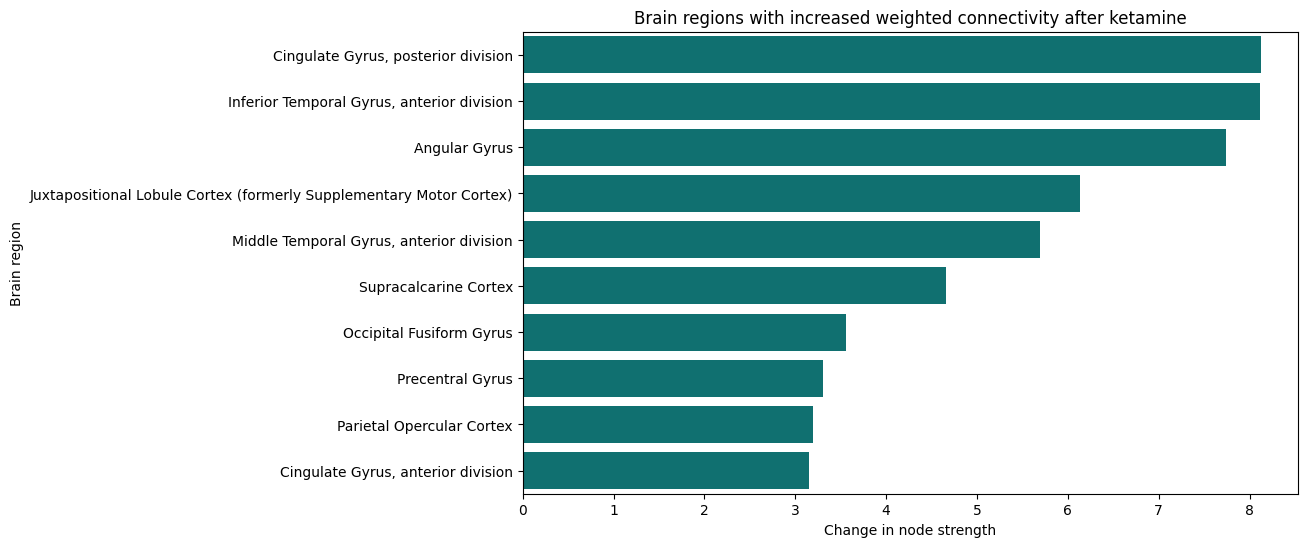

In [63]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_strength_regions,
    x="delta_strength",
    y="region",
    color='teal'
)

plt.title("Brain regions with increased weighted connectivity after ketamine")
plt.xlabel("Change in node strength")
plt.ylabel("Brain region")

plt.show()

In [17]:
bottom_strength_regions = strength_df.sort_values(
    "delta_strength",
    ascending=True
).head(10)

bottom_strength_regions

,region,baseline_strength,ketamine_strength,delta_strength
8,"Superior Temporal Gyrus, anterior division",12.151494,1.748454,-10.403040
43,Planum Polare,4.458187,-4.422488,-8.880675
47,Occipital Pole,2.924021,-4.843942,-7.767962
35,Lingual Gyrus,14.647745,6.904527,-7.743218
24,Frontal Medial Cortex,12.446594,5.997859,-6.448735
31,Cuneal Cortex,-0.475259,-6.840980,-6.365721
22,"Lateral Occipital Cortex, inferior division",2.190556,-2.215726,-4.406282
23,Intracalcarine Cortex,13.324175,9.861018,-3.463157
5,"Inferior Frontal Gyrus, pars opercularis",12.008760,9.039137,-2.969624
38,Temporal Occipital Fusiform Cortex,13.980781,11.669104,-2.311677


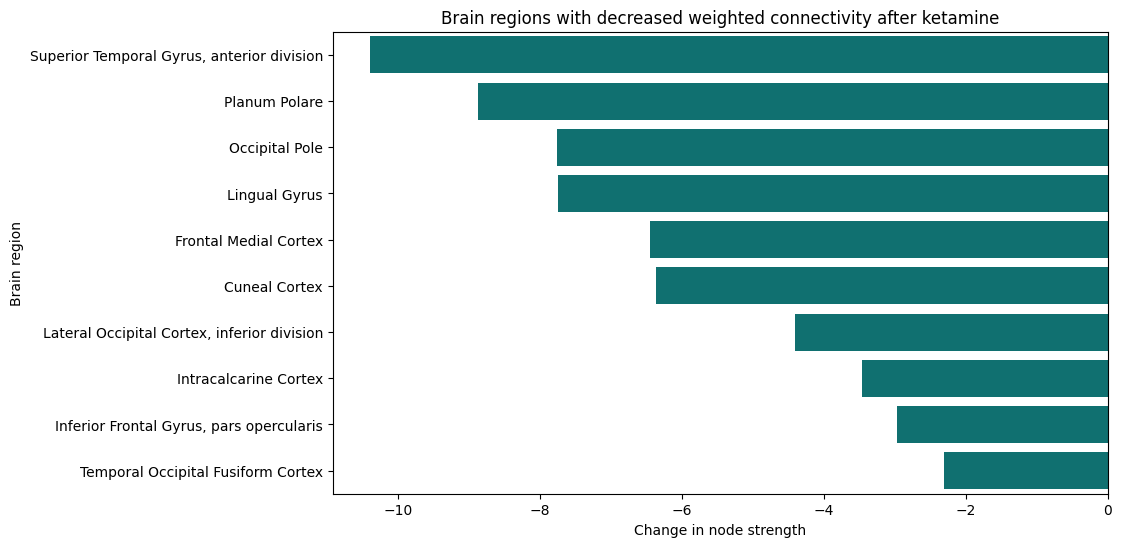

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=bottom_strength_regions,
    x="delta_strength",
    y="region",
    color='teal'
)

plt.title("Brain regions with decreased weighted connectivity after ketamine")
plt.xlabel("Change in node strength")
plt.ylabel("Brain region")

plt.show()

## Network representation of connectivity changes

In [82]:
top_region_names = top_strength_regions["region"].tolist()

In [83]:
top_region_names

['Cingulate Gyrus, posterior division',
 'Inferior Temporal Gyrus, anterior division',
 'Angular Gyrus',
 'Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)',
 'Middle Temporal Gyrus, anterior division',
 'Supracalcarine Cortex',
 'Occipital Fusiform Gyrus',
 'Precentral Gyrus',
 'Parietal Opercular Cortex',
 'Cingulate Gyrus, anterior division']

In [84]:
mean_diff_no_diag = mean_diff.copy()
np.fill_diagonal(mean_diff_no_diag, 0)

mean_diff_df = pd.DataFrame(
    mean_diff_no_diag,
    index=region_labels,
    columns=region_labels
)

sub_diff_df = mean_diff_df.loc[top_region_names, top_region_names]
sub_diff_df

,"Cingulate Gyrus, posterior division","Inferior Temporal Gyrus, anterior division",Angular Gyrus,Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex),"Middle Temporal Gyrus, anterior division",Supracalcarine Cortex,Occipital Fusiform Gyrus,Precentral Gyrus,Parietal Opercular Cortex,"Cingulate Gyrus, anterior division"
"Cingulate Gyrus, posterior division",0.000000,0.982926,0.417272,-0.025004,0.305914,-0.003436,0.292811,-0.064158,0.130272,0.126214
"Inferior Temporal Gyrus, anterior division",0.982926,0.000000,0.744820,0.530864,0.419448,-0.276375,-0.348938,0.091823,0.526308,0.483687
Angular Gyrus,0.417272,0.744820,0.000000,0.064479,-0.023739,0.672127,0.851048,-0.101586,0.588727,0.481155
Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex),-0.025004,0.530864,0.064479,0.000000,-0.282360,0.158348,0.003109,-0.091885,0.346715,0.312479
"Middle Temporal Gyrus, anterior division",0.305914,0.419448,-0.023739,-0.282360,0.000000,0.201786,0.670470,-0.434715,0.481228,0.428106
Supracalcarine Cortex,-0.003436,-0.276375,0.672127,0.158348,0.201786,0.000000,-0.451486,-0.116574,-0.289011,0.033110
Occipital Fusiform Gyrus,0.292811,-0.348938,0.851048,0.003109,0.670470,-0.451486,0.000000,-0.023134,0.328139,-0.059086
Precentral Gyrus,-0.064158,0.091823,-0.101586,-0.091885,-0.434715,-0.116574,-0.023134,0.000000,0.374834,0.187226
Parietal Opercular Cortex,0.130272,0.526308,0.588727,0.346715,0.481228,-0.289011,0.328139,0.374834,0.000000,-0.228806
"Cingulate Gyrus, anterior division",0.126214,0.483687,0.481155,0.312479,0.428106,0.033110,-0.059086,0.187226,-0.228806,0.000000


In [85]:
threshold = 0.35

In [86]:
G_diff = nx.Graph()

for region in top_region_names:
    delta_val = top_strength_regions.loc[
        top_strength_regions["region"] == region, "delta_strength"
    ].values[0]
    G_diff.add_node(region, delta_strength=delta_val)

for i, region_1 in enumerate(top_region_names):
    for j, region_2 in enumerate(top_region_names):
        if j > i:
            weight = sub_diff_df.loc[region_1, region_2]
            if weight > threshold:
                G_diff.add_edge(region_1, region_2, weight=weight)

In [87]:
print("Nodes:", G_diff.number_of_nodes())
print("Edges:", G_diff.number_of_edges())
list(G_diff.edges(data=True))[:5]

Nodes: 10
Edges: 15


[('Cingulate Gyrus, posterior division',
  'Inferior Temporal Gyrus, anterior division',
  {'weight': np.float32(0.98292553)}),
 ('Cingulate Gyrus, posterior division',
  'Angular Gyrus',
  {'weight': np.float32(0.417272)}),
 ('Inferior Temporal Gyrus, anterior division',
  'Angular Gyrus',
  {'weight': np.float32(0.74482036)}),
 ('Inferior Temporal Gyrus, anterior division',
  'Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)',
  {'weight': np.float32(0.53086436)}),
 ('Inferior Temporal Gyrus, anterior division',
  'Middle Temporal Gyrus, anterior division',
  {'weight': np.float32(0.41944787)})]

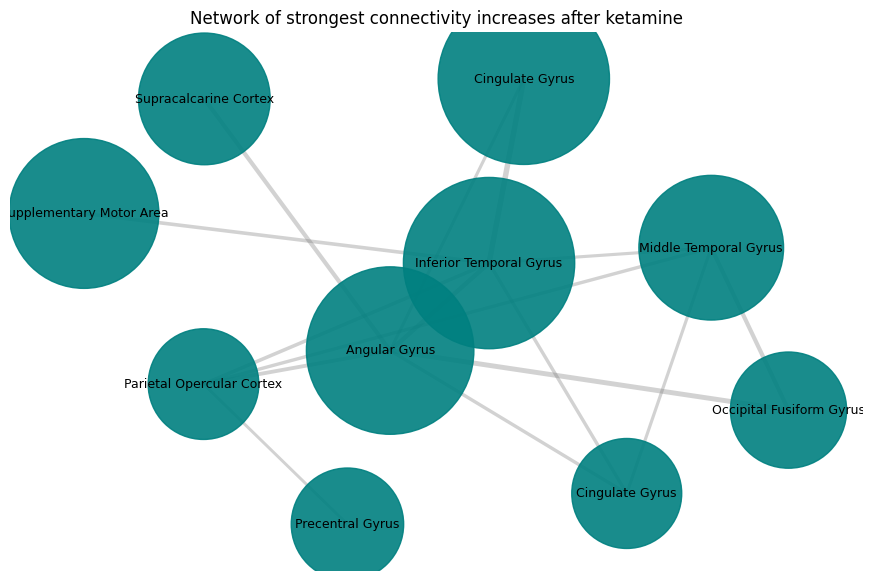

In [88]:
plt.figure(figsize=(11, 7))

pos_strength = nx.spring_layout(G_diff, seed=42, k=1.6)

labels_strength = {
    node: node
        .replace(", anterior division", "")
        .replace(", posterior division", "")
        .replace("Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)", "Supplementary Motor Area")
    for node in G_diff.nodes
}

node_sizes_strength = [
    600 + 1800 * G_diff.nodes[node]["delta_strength"]
    for node in G_diff.nodes
]

edge_widths_strength = [
    1 + 3 * G_diff[u][v]["weight"]
    for u, v in G_diff.edges
]

nx.draw_networkx_nodes(
    G_diff,
    pos_strength,
    node_size=node_sizes_strength,
    node_color="#008080",
    alpha=0.9
)

nx.draw_networkx_edges(
    G_diff,
    pos_strength,
    width=edge_widths_strength,
    alpha=0.35,
    edge_color="gray"
)

nx.draw_networkx_labels(
    G_diff,
    pos_strength,
    labels=labels_strength,
    font_size=9
)

plt.title("Network of strongest connectivity increases after ketamine")
plt.axis("off")
plt.savefig("graph_strength_network.png", dpi=300, bbox_inches="tight")
plt.show()

To visualize the most prominent connectivity changes,
a network graph was constructed from the strongest positive
connections in the mean difference matrix.

Node size represents the increase in node strength,
while edges represent connections that increased most strongly
after ketamine administration.

Several hubs emerge in this network, including regions in
the angular gyrus, temporal cortex, and cingulate cortex,
suggesting network-level reorganization following ketamine.

## Network interpretation

In [89]:
connections = []

n_regions = mean_diff.shape[0]

for i in range(n_regions):
    for j in range(i+1, n_regions):
        connections.append({
            "region_1": i,
            "region_2": j,
            "delta_connectivity": mean_diff[i, j]
        })

connections_df = pd.DataFrame(connections)

In [90]:
connections_df["region_1_name"] = connections_df["region_1"].map(lambda x: region_labels[x])
connections_df["region_2_name"] = connections_df["region_2"].map(lambda x: region_labels[x])

In [91]:
top_increases_named = connections_df.sort_values(
    "delta_connectivity",
    ascending=False
).head(10)

top_increases_named

,region_1,region_2,delta_connectivity,region_1_name,region_2_name
548,13,29,0.982926,"Inferior Temporal Gyrus, anterior division","Cingulate Gyrus, posterior division"
768,20,39,0.851048,Angular Gyrus,Occipital Fusiform Gyrus
741,19,39,0.849788,"Supramarginal Gyrus, posterior division",Occipital Fusiform Gyrus
919,27,29,0.757804,Paracingulate Gyrus,"Cingulate Gyrus, posterior division"
819,22,39,0.753948,"Lateral Occipital Cortex, inferior division",Occipital Fusiform Gyrus
539,13,20,0.744820,"Inferior Temporal Gyrus, anterior division",Angular Gyrus
218,4,41,0.744170,"Inferior Frontal Gyrus, pars triangularis",Central Opercular Cortex
889,25,40,0.737281,Juxtapositional Lobule Cortex (formerly Supple...,Frontal Opercular Cortex
440,10,26,0.699729,"Middle Temporal Gyrus, anterior division",Subcallosal Cortex
967,29,40,0.688834,"Cingulate Gyrus, posterior division",Frontal Opercular Cortex


In [92]:
G_top = nx.Graph()

for _, row in top_increases_named.iterrows():
    r1 = row["region_1_name"]
    r2 = row["region_2_name"]
    w = row["delta_connectivity"]

    G_top.add_edge(r1, r2, weight=w)

In [93]:
node_counts = {}

for node in G_top.nodes():
    node_counts[node] = G_top.degree(node)

In [94]:
short_labels = {
    node: node
        .replace(", anterior division", "")
        .replace(", posterior division", "")
        .replace("Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)", "Supplementary Motor Area")
    for node in G_top.nodes()
}

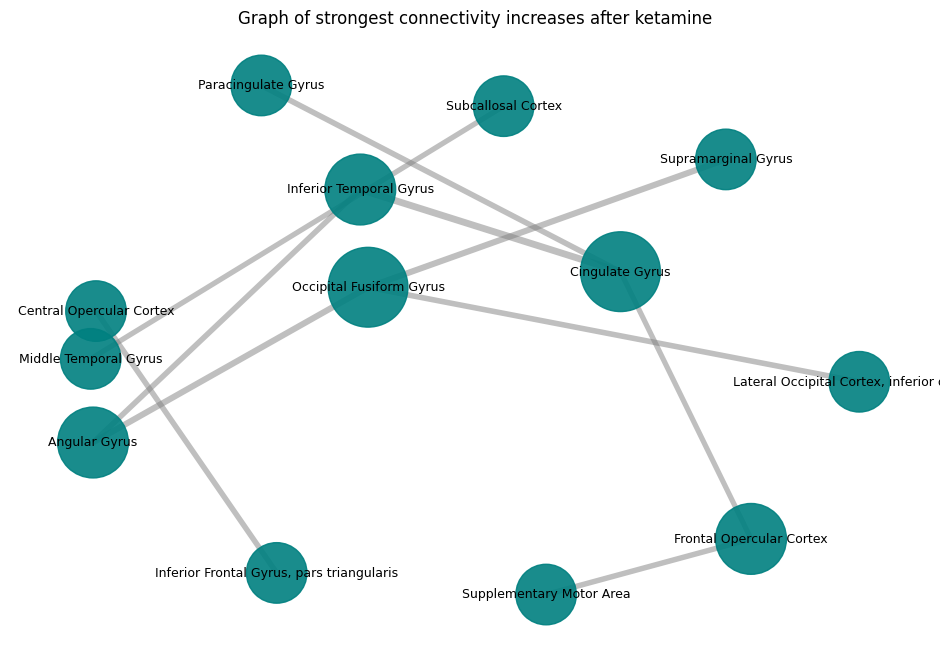

In [95]:
plt.figure(figsize=(12,8))

pos = nx.spring_layout(G_top, seed=42, k=1.4)

node_sizes = [
    1200 + 700 * node_counts[node]
    for node in G_top.nodes()
]

edge_widths = [
    1 + 4 * G_top[u][v]["weight"]
    for u,v in G_top.edges()
]

nx.draw_networkx_nodes(
    G_top,
    pos,
    node_size=node_sizes,
    node_color="#008080",
    alpha=0.9
)

nx.draw_networkx_edges(
    G_top,
    pos,
    width=edge_widths,
    edge_color="gray",
    alpha=0.5
)

nx.draw_networkx_labels(
    G_top,
    pos,
    labels=short_labels,
    font_size=9
)

plt.title("Graph of strongest connectivity increases after ketamine")
plt.axis("off")
plt.savefig("graph_top_connectivity_increases.png", dpi=300, bbox_inches="tight")
plt.show()

The network graph highlights brain regions participating in the strongest
connectivity increases following ketamine administration.

Several regions appear repeatedly in the strongest altered connections,
including the inferior temporal gyrus, cingulate cortex, and angular gyrus.

These regions belong to association cortices and large-scale brain networks
involved in cognitive integration and emotional processing.

The prominence of cingulate and paracingulate regions is consistent with
previous findings suggesting that ketamine may modulate networks involved
in mood regulation and self-referential processing.

Overall, the results suggest that ketamine-related changes are not restricted
to isolated connections but instead involve coordinated reorganization of
multiple association networks.

## Key observations

The strongest connectivity increases after ketamine involve interactions
between temporal, cingulate, and parietal association cortices.

These regions form part of large-scale networks implicated in depression,
including components of the default mode network and adjacent association systems.

## Exported artifacts

The following outputs were saved for reuse in downstream notebooks and final project documentation:

- connectivity matrices
- region labels
- top altered connections
- node strength summary
- final network figures

In [70]:
strength_df.to_csv("strength_df.csv", index=False)
top_strength_regions.to_csv("top_strength_regions.csv", index=False)
top_increases_named.to_csv("top_increases_named.csv", index=False)
bottom_strength_regions.to_csv("bottom_strength_regions.csv", index=False)

In [96]:
from google.colab import files

files.download("top_strength_regions.png")
files.download("graph_top_connectivity_increases.png")
files.download("graph_strength_network.png")

files.download("strength_df.csv")
files.download("top_strength_regions.csv")
files.download("top_increases_named.csv")
files.download("bottom_strength_regions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>